In [1]:
import os
import json
os.makedirs("../results", exist_ok=True)

# --- Third-party libraries: numerical + plotting ---
import numpy as np                               # numerical computing (arrays, arange, hstack, etc.)
import matplotlib.pyplot as plt                  # plotting and visualization (figure, subplot, ax.plot, etc.)

# --- Standard library ---
import itertools                                 # utilities for efficient looping and combinations


# --- scikit-learn: models ---
from sklearn.tree import (
    DecisionTreeClassifier,                      # decision tree classifier
)

from sklearn.neighbors import (
    KNeighborsClassifier,                        # Nearest neighbors    
)

from sklearn.svm import (
    SVC,                                         # Support Vector Machines
)

from sklearn.linear_model import (
    LogisticRegression,                          # linear model: Logistic Regression
)

# --- Ensemble methods ---
from sklearn.ensemble import (
    VotingClassifier,                  # ensemble voting (hard / soft)
    BaggingClassifier,                 # bootstrap aggregating
    RandomForestClassifier,            # random forests
    ExtraTreesClassifier,              # extremely randomized trees
    StackingClassifier,                # stacking ensembles
    AdaBoostClassifier,                # adaptive boosting
    GradientBoostingClassifier,        # gradient boosting
)


# --- scikit-learn: model selection / evaluation ---
from sklearn.model_selection import (
    train_test_split,                            # train / test split
    cross_val_score,                             # evaluate model with cross-validation
    RepeatedStratifiedKFold,                     # repeated stratified k-fold splitting
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Load the data

In [2]:
x_train = np.load("../processed/X_train_norm.npy")
x_val   = np.load("../processed/X_val_norm.npy")
x_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")

In [3]:
#Verification
print("X_train:", x_train.shape)
print("X_val:", x_val.shape)
print("X_test:", x_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


## 0 Helper function

In [4]:
def plot_res(
    data_x,
    data_y,
    weights=None,
    regressor=None,
    is_list=False,
    labels=None,
    is_data_list=False,
    data_labels=None,
    func=None,
    data_style=None,
):
    """
    Plot data points and optionally one or more fitted lines.

    Parameters
    ----------
    data_x : array-like or list of array-like
        X-values for data points. If `is_data_list` is True, this should be a list
        where each element corresponds to one dataset.
    data_y : array-like or list of array-like
        Y-values for data points, matching the structure of `data_x`.
    weights : tuple/list or list of tuples/lists, optional
        Linear model parameters. For a single model: (bias, slope).
        For multiple models (when `is_list` is True): list of (bias, slope) pairs.
    regressor : object, optional
        Model with a `.predict(X)` method (e.g. sklearn regressor). Plotted as a line.
        Expects `predict` to accept shape (n, 1). If it accepts 1D, we fall back.
    is_list : bool, default False
        Whether `weights` contains multiple (bias, slope) pairs.
    labels : list of str, optional
        Labels for the fitted lines. Automatically generated if not provided.
    is_data_list : bool, default False
        Whether `data_x` and `data_y` contain multiple datasets.
    data_labels : list of str, optional
        Labels for the datasets. Automatically generated if not provided.
    func : callable or list of callables, optional
        Transformation applied to x-values before using the weights. For multiple
        models, should be a list of callables. Defaults to identity.
    data_style : list[list[int|float,int|float]] or list[int|float,int|float], optional
        Styling for data points as [markersize, lw].
        Defaults to [[10, 0]] (points only, no connecting line).
    """
    xval = np.arange(0.0, 5.0, 0.01)  # domain for plotting fitted lines

    markers = ["o", "v", "s", "D", "X"]
    fig = plt.figure(figsize=(6, 6), dpi=100)
    ax = plt.subplot(111)

        # ----- data labels -----
    if data_labels is None:
        if is_data_list:
            data_labels = [f"data {i}" for i in range(1, len(data_x) + 1)]
        else:
            data_labels = ["data"]

    # ----- data style -----
    if data_style is None:
        data_style = [[10, 0] for _ in range(len(data_x) if is_data_list else 1)]

    # ----- plot data -----
    if is_data_list:
        for i in range(len(data_x)):
            ms, lw = data_style[i]
            ax.plot(
                data_x[i],
                data_y[i],
                label=data_labels[i],
                lw=lw,
                marker=markers[0],
                markersize=ms,
            )
    else:
        ms, lw = data_style[0]
        ax.plot(
            data_x,
            data_y,
            label=data_labels[0],
            lw=lw,
            marker=markers[0],
            markersize=ms,
        )

    # ----- line labels -----
    if labels is None:
        if is_list:
            labels = [str(i) for i in range(1, len(weights) + 1)]
        else:
                        labels = ["1"]

    # ----- functions -----
    if func is None:
        if is_list:
            func = [lambda x: x for _ in range(len(weights))]
        else:
            func = lambda x: x

    # ----- fitted lines from weights -----
    if weights is not None:
        if is_list:
            for i, w in enumerate(weights):
                ax.plot(
                    xval,
                    [w[1] * func[i](x) + w[0] for x in xval],
                    label=labels[i],
                    lw=3,
                )
        else:
            ax.plot(
                xval,
                [weights[1] * func(x) + weights[0] for x in xval],
                label=labels[0],
                lw=3,
            )

    # ----- fitted line from regressor -----
    if regressor is not None:
        try:
            yhat = regressor.predict(xval.reshape(-1, 1))
        except Exception:
            # fallback for regressors expecting 1D input
            yhat = regressor.predict(xval)

        # falls kein Label da ist oder du weights parallel nutzt, nimm etwas eindeutiges
        reg_label = (labels[0] if labels is not None and len(labels) > 0 else "regressor")
        ax.plot(xval, yhat, label=reg_label, lw=3)

    ax.legend(loc="upper left", fancybox=True, fontsize=20)
    plt.xlabel("X", fontsize=20)
    plt.ylabel("Y", fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True)

    all_y = np.hstack(data_y) if is_data_list else np.asarray(data_y)
    y_width =all_y.max()-all_y.min() 
    plt.ylim(all_y.min()-0.1*y_width, all_y.max()+0.1*y_width)
    all_x = np.hstack(data_x) if is_data_list else np.asarray(data_x)
    x_width =all_x.max()-all_x.min() 
    plt.xlim(all_x.min()-0.1*x_width, all_x.max()+0.1*x_width)


    

## 2 Single Methods

### 2.1 Decision tree

In [5]:
### Using validation set
score_train = []
score_val = []

### check score on VALIDATION data
for md in range(1, 16):
    ### train model
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf.fit(x_train,y_train)
    ### check score
    score_train.append(clf.score(x_train, y_train))
    score_val.append(clf.score(x_val, y_val))

    misclassified = (1 - score_val[-1]) * len(x_val)
    print("md={:02}".format(md),
          "score train: {:.6f}".format(score_train[-1]),
          "score val: {:.6f}".format(score_val[-1]),
          "misclassified:", int(misclassified))

md=01 score train: 0.198556 score val: 0.198333 misclassified: 4810
md=02 score train: 0.343130 score val: 0.338000 misclassified: 3971
md=03 score train: 0.488852 score val: 0.486167 misclassified: 3083
md=04 score train: 0.590556 score val: 0.592000 misclassified: 2448
md=05 score train: 0.675333 score val: 0.667667 misclassified: 1994
md=06 score train: 0.742185 score val: 0.734333 misclassified: 1594
md=07 score train: 0.793389 score val: 0.780667 misclassified: 1316
md=08 score train: 0.832093 score val: 0.815667 misclassified: 1106
md=09 score train: 0.870241 score val: 0.840667 misclassified: 956
md=10 score train: 0.904296 score val: 0.853667 misclassified: 877
md=11 score train: 0.932778 score val: 0.868000 misclassified: 792
md=12 score train: 0.952815 score val: 0.875667 misclassified: 745
md=13 score train: 0.968296 score val: 0.872833 misclassified: 762
md=14 score train: 0.978685 score val: 0.876333 misclassified: 742
md=15 score train: 0.985537 score val: 0.881667 miscla

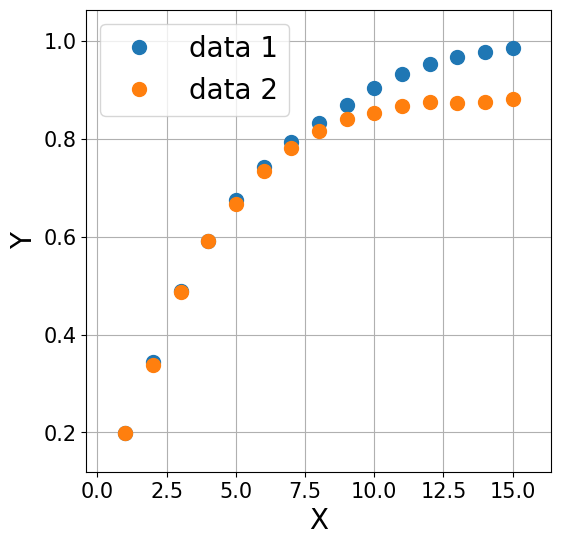

In [6]:
### plot result
max_depth = np.arange(1, len(score_train)+1, 1)
plot_res([max_depth, max_depth], [np.array(score_train), np.array(score_val)], is_data_list=True)

In [7]:
# Cross validation
kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    scores = cross_val_score(clf, x_train, y_train, cv=kfold)
    ##print(md, ": {:.6f}".format(scores.mean()))
    misclassified = (1 - scores.mean()) * len(x_val)
    print(f"max_depth={md} → CV score={scores.mean():.6f} → approx misclassified={int(misclassified)}")

max_depth=1 → CV score=0.195481 → approx misclassified=4827
max_depth=2 → CV score=0.338422 → approx misclassified=3969
max_depth=3 → CV score=0.472867 → approx misclassified=3162
max_depth=4 → CV score=0.606511 → approx misclassified=2360
max_depth=5 → CV score=0.674619 → approx misclassified=1952
max_depth=6 → CV score=0.732885 → approx misclassified=1602
max_depth=7 → CV score=0.778656 → approx misclassified=1328
max_depth=8 → CV score=0.812970 → approx misclassified=1122
max_depth=9 → CV score=0.837189 → approx misclassified=976
max_depth=10 → CV score=0.852096 → approx misclassified=887
max_depth=11 → CV score=0.860615 → approx misclassified=836
max_depth=12 → CV score=0.865256 → approx misclassified=808
max_depth=13 → CV score=0.867367 → approx misclassified=795
max_depth=14 → CV score=0.868541 → approx misclassified=788
max_depth=15 → CV score=0.868304 → approx misclassified=790
max_depth=16 → CV score=0.867689 → approx misclassified=793
max_depth=17 → CV score=0.866826 → approx

Result : validation data (md = 8), crossvalidation (md=12)

In [9]:
# model performance
#y_pred = clf.predict(x_val)

#accuracy = accuracy_score(y_val, y_pred)
#precision = precision_score(y_val, y_pred, average='macro')
#recall = recall_score(y_val, y_pred, average='macro')
#f1 = f1_score(y_val, y_pred, average='macro')

#print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
#print(f"Precision: {precision_score(y_val, y_pred, average='macro'):.4f}")
#print(f"Recall: {recall_score(y_val, y_pred, average='macro'):.4f}")
#print(f"F1-score: {f1_score(y_val, y_pred, average='macro'):.4f}")

## 3 Ensemble methods

### 3.1 Bagging

In [10]:
#n_estimators=10 (random boostrap)
for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = BaggingClassifier(estimator=clf,n_estimators=10, random_state=42)
    mclf.fit(x_train, y_train)
    
    misclassified = (1-mclf.score(x_val,y_val))*len(x_val)
    print(f"max_depth={md} → misclassified: {misclassified:.0f} → score: {mclf.score(x_val,y_val)}")

max_depth=1 → misclassified: 4810.0 → score: 0.19833333333333333
max_depth=2 → misclassified: 3700.0 → score: 0.38333333333333336
max_depth=3 → misclassified: 3053.0 → score: 0.49116666666666664
max_depth=4 → misclassified: 2330.0 → score: 0.6116666666666667
max_depth=5 → misclassified: 1741.0 → score: 0.7098333333333333
max_depth=6 → misclassified: 1260.9999999999998 → score: 0.7898333333333334
max_depth=7 → misclassified: 987.9999999999998 → score: 0.8353333333333334
max_depth=8 → misclassified: 747.0000000000003 → score: 0.8755
max_depth=9 → misclassified: 618.9999999999998 → score: 0.8968333333333334
max_depth=10 → misclassified: 521.9999999999998 → score: 0.913
max_depth=11 → misclassified: 449.9999999999997 → score: 0.925
max_depth=12 → misclassified: 419.9999999999997 → score: 0.93
max_depth=13 → misclassified: 416.00000000000017 → score: 0.9306666666666666
max_depth=14 → misclassified: 400.9999999999998 → score: 0.9331666666666667
max_depth=15 → misclassified: 394.9999999999998

In [11]:
for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = BaggingClassifier(estimator=clf,n_estimators=100, random_state=42)
    mclf.fit(x_train, y_train)
    
    misclassified = (1-mclf.score(x_val,y_val))*len(x_val)
    print(f"max_depth={md} → misclassified: {misclassified:.0f} → score: {mclf.score(x_val,y_val):.4f}")


max_depth=1 → misclassified: 3853 → score: 0.35783333333333334
max_depth=2 → misclassified: 3464 → score: 0.4226666666666667
max_depth=3 → misclassified: 2476 → score: 0.5873333333333334
max_depth=4 → misclassified: 1777 → score: 0.7038333333333333
max_depth=5 → misclassified: 1349 → score: 0.7751666666666667
max_depth=6 → misclassified: 977 → score: 0.8371666666666666
max_depth=7 → misclassified: 754 → score: 0.8743333333333333
max_depth=8 → misclassified: 593 → score: 0.9011666666666667
max_depth=9 → misclassified: 466 → score: 0.9223333333333333
max_depth=10 → misclassified: 392 → score: 0.9346666666666666
max_depth=11 → misclassified: 345 → score: 0.9425
max_depth=12 → misclassified: 315 → score: 0.9475
max_depth=13 → misclassified: 293 → score: 0.9511666666666667
max_depth=14 → misclassified: 287 → score: 0.9521666666666667
max_depth=15 → misclassified: 288 → score: 0.952
max_depth=16 → misclassified: 277 → score: 0.9538333333333333
max_depth=17 → misclassified: 275 → score: 0.954

### 3.2 Random Forest

In [12]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=10, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3454 → score: 0.424333
max_depth=2 → misclassified: 2488 → score: 0.585333
max_depth=3 → misclassified: 1943 → score: 0.676167
max_depth=4 → misclassified: 1299 → score: 0.783500
max_depth=5 → misclassified: 1079 → score: 0.820167
max_depth=6 → misclassified: 907 → score: 0.848833
max_depth=7 → misclassified: 728 → score: 0.878667
max_depth=8 → misclassified: 638 → score: 0.893667
max_depth=9 → misclassified: 528 → score: 0.912000
max_depth=10 → misclassified: 447 → score: 0.925500
max_depth=11 → misclassified: 398 → score: 0.933667
max_depth=12 → misclassified: 384 → score: 0.936000
max_depth=13 → misclassified: 375 → score: 0.937500
max_depth=14 → misclassified: 345 → score: 0.942500
max_depth=15 → misclassified: 353 → score: 0.941167
max_depth=16 → misclassified: 337 → score: 0.943833
max_depth=17 → misclassified: 346 → score: 0.942333
max_depth=18 → misclassified: 343 → score: 0.942833


In [13]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=100, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2892 → score: 0.518000
max_depth=2 → misclassified: 2153 → score: 0.641167
max_depth=3 → misclassified: 1656 → score: 0.724000
max_depth=4 → misclassified: 1106 → score: 0.815667
max_depth=5 → misclassified: 890 → score: 0.851667
max_depth=6 → misclassified: 674 → score: 0.887667
max_depth=7 → misclassified: 545 → score: 0.909167
max_depth=8 → misclassified: 470 → score: 0.921667
max_depth=9 → misclassified: 400 → score: 0.933333
max_depth=10 → misclassified: 339 → score: 0.943500
max_depth=11 → misclassified: 305 → score: 0.949167
max_depth=12 → misclassified: 265 → score: 0.955833
max_depth=13 → misclassified: 244 → score: 0.959333
max_depth=14 → misclassified: 234 → score: 0.961000
max_depth=15 → misclassified: 218 → score: 0.963667
max_depth=16 → misclassified: 212 → score: 0.964667
max_depth=17 → misclassified: 209 → score: 0.965167
max_depth=18 → misclassified: 204 → score: 0.966000


In [14]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=1000, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2754 → score: 0.541000
max_depth=2 → misclassified: 2186 → score: 0.635667
max_depth=3 → misclassified: 1499 → score: 0.750167
max_depth=4 → misclassified: 1089 → score: 0.818500
max_depth=5 → misclassified: 836 → score: 0.860667
max_depth=6 → misclassified: 653 → score: 0.891167
max_depth=7 → misclassified: 535 → score: 0.910833
max_depth=8 → misclassified: 449 → score: 0.925167
max_depth=9 → misclassified: 381 → score: 0.936500
max_depth=10 → misclassified: 324 → score: 0.946000
max_depth=11 → misclassified: 289 → score: 0.951833
max_depth=12 → misclassified: 260 → score: 0.956667
max_depth=13 → misclassified: 245 → score: 0.959167
max_depth=14 → misclassified: 223 → score: 0.962833
max_depth=15 → misclassified: 217 → score: 0.963833
max_depth=16 → misclassified: 208 → score: 0.965333
max_depth=17 → misclassified: 193 → score: 0.967833
max_depth=18 → misclassified: 193 → score: 0.967833


### ExtraTrees

In [15]:
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=10, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3448 → score: 0.425333
max_depth=2 → misclassified: 2787 → score: 0.535500
max_depth=3 → misclassified: 2231 → score: 0.628167
max_depth=4 → misclassified: 1726 → score: 0.712333
max_depth=5 → misclassified: 1302 → score: 0.783000
max_depth=6 → misclassified: 1075 → score: 0.820833
max_depth=7 → misclassified: 914 → score: 0.847667
max_depth=8 → misclassified: 734 → score: 0.877667
max_depth=9 → misclassified: 645 → score: 0.892500
max_depth=10 → misclassified: 546 → score: 0.909000
max_depth=11 → misclassified: 472 → score: 0.921333
max_depth=12 → misclassified: 420 → score: 0.930000
max_depth=13 → misclassified: 400 → score: 0.933333
max_depth=14 → misclassified: 391 → score: 0.934833
max_depth=15 → misclassified: 361 → score: 0.939833
max_depth=16 → misclassified: 337 → score: 0.943833
max_depth=17 → misclassified: 325 → score: 0.945833
max_depth=18 → misclassified: 324 → score: 0.946000


In [16]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=100, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3020 → score: 0.496667
max_depth=2 → misclassified: 2234 → score: 0.627667
max_depth=3 → misclassified: 1848 → score: 0.692000
max_depth=4 → misclassified: 1354 → score: 0.774333
max_depth=5 → misclassified: 1036 → score: 0.827333
max_depth=6 → misclassified: 797 → score: 0.867167
max_depth=7 → misclassified: 663 → score: 0.889500
max_depth=8 → misclassified: 538 → score: 0.910333
max_depth=9 → misclassified: 452 → score: 0.924667
max_depth=10 → misclassified: 400 → score: 0.933333
max_depth=11 → misclassified: 342 → score: 0.943000
max_depth=12 → misclassified: 301 → score: 0.949833
max_depth=13 → misclassified: 274 → score: 0.954333
max_depth=14 → misclassified: 254 → score: 0.957667
max_depth=15 → misclassified: 239 → score: 0.960167
max_depth=16 → misclassified: 215 → score: 0.964167
max_depth=17 → misclassified: 197 → score: 0.967167
max_depth=18 → misclassified: 202 → score: 0.966333


In [17]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=1000, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2843 → score: 0.526167
max_depth=2 → misclassified: 2193 → score: 0.634500
max_depth=3 → misclassified: 1669 → score: 0.721833
max_depth=4 → misclassified: 1292 → score: 0.784667
max_depth=5 → misclassified: 979 → score: 0.836833
max_depth=6 → misclassified: 776 → score: 0.870667
max_depth=7 → misclassified: 621 → score: 0.896500
max_depth=8 → misclassified: 508 → score: 0.915333
max_depth=9 → misclassified: 445 → score: 0.925833
max_depth=10 → misclassified: 382 → score: 0.936333
max_depth=11 → misclassified: 333 → score: 0.944500
max_depth=12 → misclassified: 298 → score: 0.950333
max_depth=13 → misclassified: 260 → score: 0.956667
max_depth=14 → misclassified: 234 → score: 0.961000
max_depth=15 → misclassified: 212 → score: 0.964667
max_depth=16 → misclassified: 207 → score: 0.965500
max_depth=17 → misclassified: 189 → score: 0.968500
max_depth=18 → misclassified: 189 → score: 0.968500


### AdaBoost

Work with weak lerner

In [27]:
clf1 = DecisionTreeClassifier(max_depth=1, random_state=42)
clf2 = DecisionTreeClassifier(max_depth=2, random_state=42)
clf3 = DecisionTreeClassifier(max_depth=4, random_state=42)
clf4 = DecisionTreeClassifier(max_depth=8, random_state=42)

In [28]:
### setup of model
n_estimators = 10
mclf1 = AdaBoostClassifier(estimator=clf1, n_estimators=n_estimators, random_state=42)
mclf2 = AdaBoostClassifier(estimator=clf2, n_estimators=n_estimators, random_state=42)
mclf3 = AdaBoostClassifier(estimator=clf3, n_estimators=n_estimators, random_state=42)
mclf4 = AdaBoostClassifier(estimator=clf4, n_estimators=n_estimators, random_state=42)


mclf1.fit(x_train, y_train)
print((1-mclf1.score(x_val,y_val))*len(x_val))

mclf2.fit(x_train, y_train)
print((1-mclf2.score(x_val,y_val))*len(x_val))

mclf3.fit(x_train, y_train)
print((1-mclf3.score(x_val,y_val))*len(x_val))

mclf4.fit(x_train, y_train)
print((1-mclf4.score(x_val,y_val))*len(x_val))

4017.0
2390.0
1266.9999999999998
508.0


In [29]:
### setup of model
n_estimators = 100
mclf1 = AdaBoostClassifier(estimator=clf1, n_estimators=n_estimators, random_state=42)
mclf2 = AdaBoostClassifier(estimator=clf2, n_estimators=n_estimators, random_state=42)
mclf3 = AdaBoostClassifier(estimator=clf3, n_estimators=n_estimators, random_state=42)
mclf4 = AdaBoostClassifier(estimator=clf4, n_estimators=n_estimators, random_state=42)


mclf1.fit(x_train, y_train)
print((1-mclf1.score(x_val,y_val))*len(x_val))

mclf2.fit(x_train, y_train)
print((1-mclf2.score(x_val,y_val))*len(x_val))

mclf3.fit(x_train, y_train)
print((1-mclf3.score(x_val,y_val))*len(x_val))

mclf4.fit(x_train, y_train)
print((1-mclf4.score(x_val,y_val))*len(x_val))

1531.9999999999998
1111.0000000000002
588.9999999999998
229.00000000000009


In [ ]:
### setup of model
n_estimators = 1000
mclf1 = AdaBoostClassifier(estimator=clf1, n_estimators=n_estimators, random_state=42)
mclf2 = AdaBoostClassifier(estimator=clf2, n_estimators=n_estimators, random_state=42)
mclf3 = AdaBoostClassifier(estimator=clf3, n_estimators=n_estimators, random_state=42)
mclf4 = AdaBoostClassifier(estimator=clf4, n_estimators=n_estimators, random_state=42)


mclf1.fit(x_train, y_train)
print((1-mclf1.score(x_val,y_val))*len(x_val))

mclf2.fit(x_train, y_train)
print((1-mclf2.score(x_val,y_val))*len(x_val))

mclf3.fit(x_train, y_train)
print((1-mclf3.score(x_val,y_val))*len(x_val))

mclf4.fit(x_train, y_train)
print((1-mclf4.score(x_val,y_val))*len(x_val))

estimators=01 score train: 9067.000000 score validation: 1108.000000
estimators=02 score train: 9067.000000 score validation: 1106.000000
estimators=03 score train: 6709.000000 score validation: 905.000000
estimators=04 score train: 5367.000000 score validation: 773.000000
estimators=05 score train: 5420.000000 score validation: 753.000000
estimators=06 score train: 4589.000000 score validation: 685.000000
estimators=07 score train: 3626.000000 score validation: 617.000000
estimators=08 score train: 3465.000000 score validation: 602.000000
estimators=09 score train: 3061.000000 score validation: 566.000000
estimators=10 score train: 2668.000000 score validation: 546.000000
estimators=11 score train: 2714.000000 score validation: 555.000000
estimators=12 score train: 2339.000000 score validation: 554.000000
estimators=13 score train: 2198.000000 score validation: 513.000000
estimators=14 score train: 1821.000000 score validation: 478.000000
estimators=15 score train: 1799.000000 score v

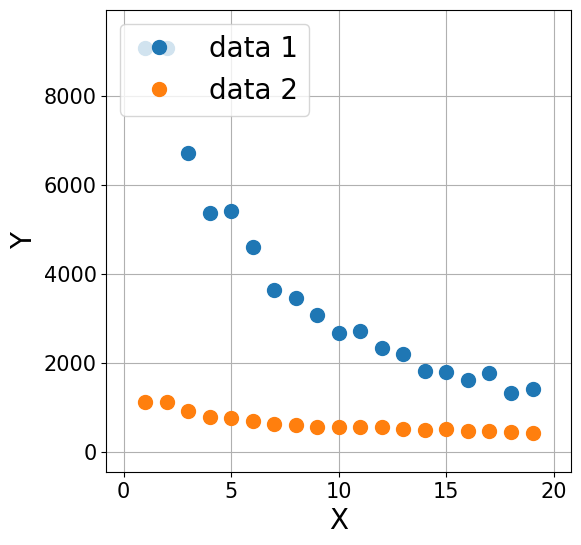

In [25]:
score_train = []
score_val = []

for n_estimators in range(1, 20, 1):
    ### setup of model
    mclf1 = AdaBoostClassifier(estimator=clf4, n_estimators=n_estimators, random_state=42)
    mclf1.fit(x_train, y_train)
    ### check score
    y_score_train = mclf1.predict_proba(x_train)[:,1]
    y_score_val = mclf1.predict_proba(x_val)[:,1]
    score_train.append((1-mclf1.score(x_train,y_train))*len(x_train))
    score_val.append((1-mclf1.score(x_val,y_val))*len(x_val))
    print("estimators={:02}".format(n_estimators), "Misclassified train: {:.6f}".format(score_train[-1]),
          "Misclassified validation: {:.6f}".format(score_val[-1]))


estims = np.arange(1, len(score_train)+1, 1)
plot_res([estims, estims], [np.array(score_train), np.array(score_val)], is_data_list=True)

In [ ]:
score_train = []
score_val = []

for n_estimators in range(1, 2002, 100):
    ### setup of model
    mclf1 = AdaBoostClassifier(estimator=clf4, n_estimators=n_estimators, random_state=42)
    mclf1.fit(x_train, y_train)
    ### check score
    y_score_train = mclf1.predict_proba(x_train)[:,1]
    y_score_val = mclf1.predict_proba(x_val)[:,1]
    score_train.append((1-mclf1.score(x_train,y_train))*len(x_train))
    score_val.append((1-mclf1.score(x_val,y_val))*len(x_val))
    print("estimators={:02}".format(n_estimators), "Misclassified train: {:.6f}".format(score_train[-1]),
          "Misclassified validation: {:.6f}".format(score_val[-1]))


estims = np.arange(1, len(score_train)+1, 1)
plot_res([estims, estims], [np.array(score_train), np.array(score_val)], is_data_list=True)

### Load the model results for comparison

In [ ]:
### ../results/final_comparison.ipynb

In [ ]:
# those are just exemples :)
# You can add additional dictionaries to results depending on your model’s outputs or training information.
results = {
    "model": "Ensemble Voting",

    "best_params": {
        "method": "VotingClassifier",
        "voting": "hard",
        "models": ["KNN", "DecisionTree", "LogisticRegression"]
    },
    "metrics": {
        "accuracy": 0.6,
        "precision": 0.57,
        "recall": 0.08,
        "f1": 0.8,
    },
        "scores": {
        "train_accuracy": 0.88,
        "val_accuracy": 0.84,
        "test_accuracy": 0.54,
    },
}
with open("../results/ensemble.json", "w") as f:
    json.dump(results, f, indent=2)